# Part III: Downstream Task with Learned Representations

In [1]:
# I use LSTM for sentiment analysis 
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import numpy as np
import pandas as pd
from datasets import load_dataset
from tqdm import tqdm
import time
import math
import re
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, LSTM, Flatten, Dropout, Dense, Input
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.optimizers import Adam

c:\Users\jenni\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset = load_dataset("stanfordnlp/imdb")
train_lines = dataset["train"].to_pandas()
test_lines = dataset["test"].to_pandas()

In [3]:
X_train = train_lines['text']
X_test = test_lines['text']
Y_train = np.array(train_lines['label'], dtype= np.int32)
Y_test = np.array(test_lines['label'], dtype = np.int32)

In [4]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train)
train_sequences = tokenizer.texts_to_sequences(X_train)
test_sequences = tokenizer.texts_to_sequences(X_test)

In [5]:
max_len = 100
train_sequences = pad_sequences(train_sequences, maxlen=max_len, padding='post')
test_sequences = pad_sequences(test_sequences, maxlen=max_len, padding='post')

In [6]:
vocab_size = len(tokenizer.word_index) + 1

In [7]:
seq_len = 100
batch_size = 32
embed_size = 128
hidden_size = 256
num_layers = 2
learning_rate = 0.001
num_epochs = 5

In [8]:
def build_language_model(vocab_size, embed_size=embed_size, lstm_units=hidden_size, max_len=100):
    model = Sequential([
        Input(shape=(max_len-1,)), 
        Embedding(vocab_size, embed_size),
        LSTM(lstm_units, return_sequences=True),
        LSTM(lstm_units, return_sequences=False),
        Dense(vocab_size, activation='softmax')  
    ])
    model.compile(loss='sparse_categorical_crossentropy', 
                  optimizer='adam', 
                  metrics=['accuracy'])
    return model

In [9]:
X_lm = train_sequences[:, :-1]  
Y_lm = train_sequences[:, -1]   

# Train the language model
lm_model = build_language_model(vocab_size)
lm_model.fit(X_lm, Y_lm, epochs= num_epochs, batch_size = batch_size)

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 159s 202ms/step - accuracy: 0.1308 - loss: 7.5090
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 164s 209ms/step - accuracy: 0.1853 - loss: 6.1365
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 163s 208ms/step - accuracy: 0.2049 - loss: 5.8745
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 163s 209ms/step - accuracy: 0.2196 - loss: 5.6539
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 163s 209ms/step - accuracy: 0.2335 - loss: 5.4354


In [10]:
new_input = Input(shape=(max_len-1,), dtype='int32', name='new_input')

# Pass through each layer of the trained model
x = lm_model.layers[0](new_input)  
x = lm_model.layers[1](x)         
x = lm_model.layers[2](x)          

# Create the feature extractor
feature_extractor = Model(inputs=new_input, outputs=x)

In [11]:
train_sequences = train_sequences[:, :-1]  # drop the last word
test_sequences = test_sequences[:, :-1]

train_reps = feature_extractor.predict(train_sequences)
test_reps = feature_extractor.predict(test_sequences)

print(f"Original text shape: {train_sequences.shape}")
print(f"Extracted representations shape: {train_reps.shape}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 46s 59ms/step
782/782 ━━━━━━━━━━━━━━━━━━━━ 45s 58ms/step
Original text shape: (25000, 99)
Extracted representations shape: (25000, 256)


In [12]:
classifier = Sequential([
    Input(shape=(256,), dtype='int32'),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

classifier.summary()
classifier.compile(loss='binary_crossentropy',
              optimizer=Adam(learning_rate = learning_rate),
              metrics=['accuracy'])

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,561 (72.50 KB)

 Trainable params: 18,561 (72.50 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
start_time = time.time()
train_history = classifier.fit(train_reps, Y_train, batch_size=32, epochs= num_epochs, verbose=1,
                          validation_split=0.2)
end_time = time.time()

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6249 - loss: 0.6627 - val_accuracy: 0.0278 - val_loss: 0.9787
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6291 - loss: 0.6590 - val_accuracy: 0.0278 - val_loss: 0.9570
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6301 - loss: 0.6578 - val_accuracy: 0.0318 - val_loss: 0.9411
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6309 - loss: 0.6572 - val_accuracy: 0.0314 - val_loss: 0.9801
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6313 - loss: 0.6575 - val_accuracy: 0.0418 - val_loss: 0.9363


In [14]:
print("Training time: ", end_time - start_time)

Training time:  4.255056858062744


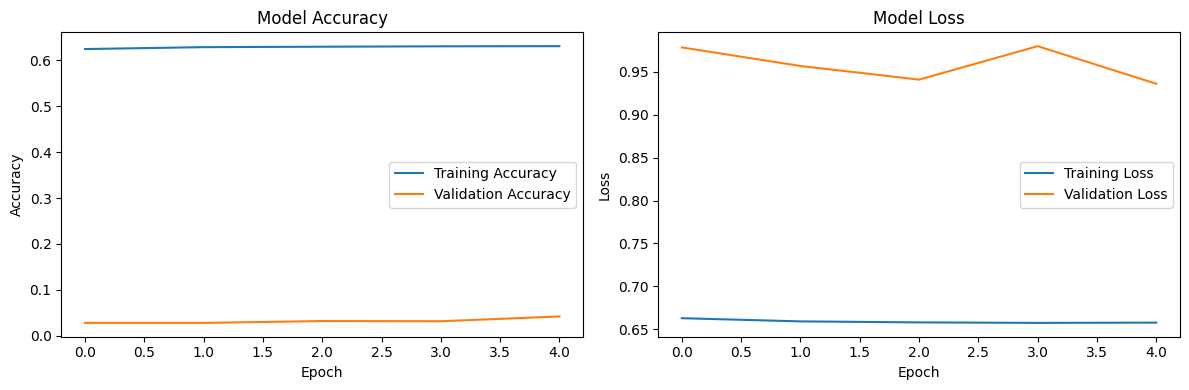

In [15]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_history.history['accuracy'], label='Training Accuracy')
plt.plot(train_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_history.history['loss'], label='Training Loss')
plt.plot(train_history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [16]:
test_loss, test_accuracy = classifier.evaluate(test_reps, Y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

Test Accuracy: 0.5121
Test Loss: 0.7137
